In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("../data/processed/enriched_logon.csv")
df.shape

(3366264, 14)

In [5]:
df.head()


,user,window,logon_count,logoff_count,unique_pcs,hour,avg_logon,std_logon,avg_pcs,std_pcs,z_logon,z_pcs,night_flag,behavior_score
0,AAB0162,2010-01-04 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,1.000703,0.0,False,0.400281
1,AAB0162,2010-01-04 18:00:00,0,1,1,18,0.499297,0.500351,1.0,0.0,-0.997892,0.0,False,0.399157
2,AAB0162,2010-01-05 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,1.000703,0.0,False,0.400281
3,AAB0162,2010-01-05 18:00:00,0,1,1,18,0.499297,0.500351,1.0,0.0,-0.997892,0.0,False,0.399157
4,AAB0162,2010-01-06 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,1.000703,0.0,False,0.400281


In [6]:
user_variability = df.groupby("user").agg({
    "logon_count": ["mean", "std"],
    "unique_pcs": ["mean", "std"],
    "hour": ["mean", "std"]
})

print(user_variability.describe())

       logon_count                unique_pcs                      hour  \
              mean          std         mean          std         mean   
count  4000.000000  4000.000000  4000.000000  4000.000000  4000.000000   
mean      0.558038     0.499832     1.007113     0.038529    12.158502   
std       0.081835     0.019571     0.023546     0.080672     0.709715   
min       0.498592     0.476786     1.000000     0.000000     9.972376   
25%       0.500000     0.494049     1.000000     0.000000    11.574087   
50%       0.500000     0.500351     1.000000     0.000000    12.057024   
75%       0.640404     0.500351     1.003428     0.058482    12.573034   
max       0.896739     0.664649     1.176401     0.487452    14.444653   

                    
               std  
count  4000.000000  
mean      4.567149  
std       0.727658  
min       2.880384  
25%       4.010495  
50%       4.512516  
75%       5.003515  
max       7.290194  


In [7]:
# Temporal Behavior Patterns-->Check whether users have consistent activity hours.
hour_distribution = df.groupby("user")["hour"].std()

print(hour_distribution.describe())

count    4000.000000
mean        4.567149
std         0.727658
min         2.880384
25%         4.010495
50%         4.512516
75%         5.003515
max         7.290194
Name: hour, dtype: float64


In [8]:
# Device Usage Diversity---->Check if users normally use very few devices.
device_behavior = df.groupby("user")["unique_pcs"].mean()

print(device_behavior.describe())

count    4000.000000
mean        1.007113
std         0.023546
min         1.000000
25%         1.000000
50%         1.000000
75%         1.003428
max         1.176401
Name: unique_pcs, dtype: float64


In [9]:
# Logon Burst Potential---->Check whether login counts vary.

logon_behavior = df.groupby("user")["logon_count"].mean()

print(logon_behavior.describe())

count    4000.000000
mean        0.558038
std         0.081835
min         0.498592
25%         0.500000
50%         0.500000
75%         0.640404
max         0.896739
Name: logon_count, dtype: float64


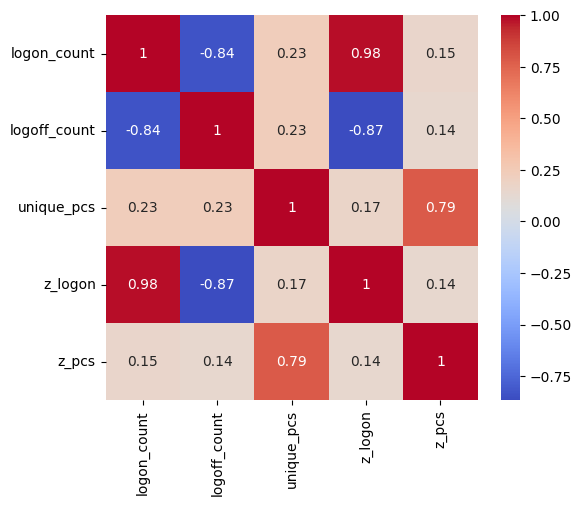

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["logon_count","logoff_count","unique_pcs","z_logon","z_pcs"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

<h2>Setting up the new featuers</h2>

In [11]:
"""
V5 Feature Engineering Module
=============================

Purpose
-------
This module enriches the behavioral dataset with additional features that
capture deviation, temporal behavior, and activity intensity.

These features help anomaly detection models (Isolation Forest) better
separate anomalous behavior from normal activity.

The function expects the original enriched_logon dataframe used in V3.

Input Columns Required
----------------------
user
window
logon_count
logoff_count
unique_pcs
hour
avg_logon
avg_pcs
mean_activity_hour (optional but recommended)

Output
------
Returns a dataframe with additional engineered features ready for modeling.
"""

import pandas as pd
import numpy as np


def generate_v5_features(df):
    """
    Generate additional behavioral features for Version V5.

    Parameters
    ----------
    df : pd.DataFrame
        Original dataset containing hourly user activity.

    Returns
    -------
    df : pd.DataFrame
        DataFrame enriched with new behavioral features.
    """

    # Make a copy to avoid modifying original data
    df = df.copy()

    # ---------------------------------------------------------
    # 1. Behavioral Deviation Features
    # ---------------------------------------------------------
    # These measure how far current activity deviates from the user's baseline.

    # Deviation of current login activity from user's average login behavior
    df["logon_deviation"] = df["logon_count"] - df["avg_logon"]

    # Deviation in device usage from normal device behavior
    df["device_deviation"] = df["unique_pcs"] - df["avg_pcs"]

    # ---------------------------------------------------------
    # 2. Behavioral Ratio Features
    # ---------------------------------------------------------
    # Ratios normalize activity patterns and help detect abnormal spikes.

    # Ratio between logins and logoffs
    # Helps identify unusual session patterns
    df["logon_logoff_ratio"] = df["logon_count"] / (df["logoff_count"] + 1)

    # Burst score measures how much login activity exceeds the user's average
    df["burst_score"] = df["logon_count"] / (df["avg_logon"] + 1)

    # Device ratio measures relative increase in device usage
    df["device_ratio"] = df["unique_pcs"] / (df["avg_pcs"] + 1)

    # ---------------------------------------------------------
    # 3. Temporal Behavior Features
    # ---------------------------------------------------------
    # These capture time-related anomalies in user behavior.

    # Deviation from user's typical activity hour
    if "mean_activity_hour" in df.columns:
        df["hour_deviation"] = abs(df["hour"] - df["mean_activity_hour"])
    else:
        # If mean activity hour is not available, approximate using hour mean per user
        user_hour_mean = df.groupby("user")["hour"].transform("mean")
        df["hour_deviation"] = abs(df["hour"] - user_hour_mean)

    # ---------------------------------------------------------
    # 4. Session Gap Feature
    # ---------------------------------------------------------
    # Measures time difference between consecutive user activities.

    # Convert window column to datetime if not already
    df["window"] = pd.to_datetime(df["window"])

    # Sort data so session gap calculation is correct
    df = df.sort_values(["user", "window"])

    # Compute time difference between consecutive sessions per user
    df["session_gap"] = df.groupby("user")["window"].diff().dt.total_seconds()/3600

    # Replace NaN values (first session per user) with 0
    df["session_gap"] = df["session_gap"].fillna(0)

    # ---------------------------------------------------------
    # 5. Night Activity Feature
    # ---------------------------------------------------------
    # Measures whether the user is active during night hours.

    # Night hours defined as 10 PM to 6 AM
    df["night_activity_flag"] = ((df["hour"] >= 22) | (df["hour"] <= 6)).astype(int)

    return df

In [12]:
df_new_features=generate_v5_features(df)

In [13]:
df_new_features.head().round(2)

,user,window,logon_count,logoff_count,unique_pcs,hour,avg_logon,std_logon,avg_pcs,std_pcs,...,night_flag,behavior_score,logon_deviation,device_deviation,logon_logoff_ratio,burst_score,device_ratio,hour_deviation,session_gap,night_activity_flag
0,AAB0162,2010-01-04 07:00:00,1,0,1,7,0.5,0.5,1.0,0.0,...,False,0.4,0.5,0.0,1.0,0.67,0.5,5.53,0.0,0
1,AAB0162,2010-01-04 18:00:00,0,1,1,18,0.5,0.5,1.0,0.0,...,False,0.4,-0.5,0.0,0.0,0.00,0.5,5.47,11.0,0
2,AAB0162,2010-01-05 07:00:00,1,0,1,7,0.5,0.5,1.0,0.0,...,False,0.4,0.5,0.0,1.0,0.67,0.5,5.53,13.0,0
3,AAB0162,2010-01-05 18:00:00,0,1,1,18,0.5,0.5,1.0,0.0,...,False,0.4,-0.5,0.0,0.0,0.00,0.5,5.47,11.0,0
4,AAB0162,2010-01-06 07:00:00,1,0,1,7,0.5,0.5,1.0,0.0,...,False,0.4,0.5,0.0,1.0,0.67,0.5,5.53,13.0,0


In [14]:
df_new_features.describe().round(2)

,window,logon_count,logoff_count,unique_pcs,hour,avg_logon,std_logon,avg_pcs,std_pcs,z_logon,z_pcs,behavior_score,logon_deviation,device_deviation,logon_logoff_ratio,burst_score,device_ratio,hour_deviation,session_gap,night_activity_flag
count,3366264,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00
mean,2010-09-10 22:05:15.077961728,0.58,0.47,1.01,12.14,0.58,0.50,1.01,0.06,-0.00,0.00,0.42,-0.00,-0.00,0.56,0.36,0.50,4.34,13.98,0.04
min,2010-01-02 02:00:00,0.00,0.00,1.00,0.00,0.50,0.48,1.00,0.00,-1.59,-0.38,0.19,-0.90,-0.18,0.00,0.00,0.46,0.00,0.00,0.00
25%,2010-05-04 17:00:00,0.00,0.00,1.00,8.00,0.50,0.49,1.00,0.00,-1.00,-0.08,0.32,-0.50,-0.01,0.00,0.00,0.50,3.99,6.00,0.00
50%,2010-09-08 09:00:00,1.00,0.00,1.00,12.00,0.52,0.50,1.00,0.00,0.69,0.00,0.40,0.34,0.00,1.00,0.60,0.50,4.50,10.00,0.00
75%,2011-01-19 08:00:00,1.00,1.00,1.00,17.00,0.64,0.50,1.01,0.09,0.97,0.00,0.40,0.49,0.00,1.00,0.66,0.50,5.04,15.00,0.00
max,2011-06-01 07:00:00,5.00,5.00,6.00,23.00,0.90,0.66,1.18,0.49,7.02,26.11,9.90,4.18,4.84,3.00,2.74,2.78,13.46,114.00,1.00
std,NaN,0.51,0.51,0.12,4.70,0.09,0.03,0.03,0.10,1.00,0.56,0.25,0.50,0.12,0.49,0.32,0.06,1.66,16.02,0.19


In [15]:
df_new_features['session_gap']

0           0.0
1          11.0
2          13.0
3          11.0
4          13.0
           ... 
3366259     7.0
3366260    17.0
3366261     7.0
3366262    89.0
3366263     7.0
Name: session_gap, Length: 3366264, dtype: float64

In [16]:
df_new_features.isna().sum()

user                   0
window                 0
logon_count            0
logoff_count           0
unique_pcs             0
hour                   0
avg_logon              0
std_logon              0
avg_pcs                0
std_pcs                0
z_logon                0
z_pcs                  0
night_flag             0
behavior_score         0
logon_deviation        0
device_deviation       0
logon_logoff_ratio     0
burst_score            0
device_ratio           0
hour_deviation         0
session_gap            0
night_activity_flag    0
dtype: int64

In [17]:
df_new_features

,user,window,logon_count,logoff_count,unique_pcs,hour,avg_logon,std_logon,avg_pcs,std_pcs,...,night_flag,behavior_score,logon_deviation,device_deviation,logon_logoff_ratio,burst_score,device_ratio,hour_deviation,session_gap,night_activity_flag
0,AAB0162,2010-01-04 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,...,False,0.400281,0.500703,0.0,1.0,0.666979,0.5,5.534459,0.0,0
1,AAB0162,2010-01-04 18:00:00,0,1,1,18,0.499297,0.500351,1.0,0.0,...,False,0.399157,-0.499297,0.0,0.0,0.000000,0.5,5.465541,11.0,0
2,AAB0162,2010-01-05 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,...,False,0.400281,0.500703,0.0,1.0,0.666979,0.5,5.534459,13.0,0
3,AAB0162,2010-01-05 18:00:00,0,1,1,18,0.499297,0.500351,1.0,0.0,...,False,0.399157,-0.499297,0.0,0.0,0.000000,0.5,5.465541,11.0,0
4,AAB0162,2010-01-06 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,...,False,0.400281,0.500703,0.0,1.0,0.666979,0.5,5.534459,13.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3366259,ZZO2997,2011-05-26 14:00:00,0,1,1,14,0.500000,0.500351,1.0,0.0,...,False,0.399719,-0.500000,0.0,0.0,0.000000,0.5,3.485955,7.0,0
3366260,ZZO2997,2011-05-27 07:00:00,1,0,1,7,0.500000,0.500351,1.0,0.0,...,False,0.399719,0.500000,0.0,1.0,0.666667,0.5,3.514045,17.0,0
3366261,ZZO2997,2011-05-27 14:00:00,0,1,1,14,0.500000,0.500351,1.0,0.0,...,False,0.399719,-0.500000,0.0,0.0,0.000000,0.5,3.485955,7.0,0
3366262,ZZO2997,2011-05-31 07:00:00,1,0,1,7,0.500000,0.500351,1.0,0.0,...,False,0.399719,0.500000,0.0,1.0,0.666667,0.5,3.514045,89.0,0


<h2>USING THE V4 PIPELINE</h2>

In [18]:
from v4_pipeline import run_full_v4_pipeline, display_metrics
df_result, metrics = run_full_v4_pipeline(df_new_features)

In [19]:
df_result

,user,window,logon_count,logoff_count,unique_pcs,hour,z_logon,z_pcs,night_flag,behavior_score,...,avg_logon,std_logon,avg_pcs,std_pcs,Shift,cluster_id,cluster_if_score,cluster_if_pred,is_cluster_anomaly,is_anomaly_final
0,AAB0398,2010-01-04 15:00:00,0,1,1,15,-0.559836,-0.073959,False,0.399719,...,0.578652,1.033609,1.022472,0.303844,Day,1,0.060802,1,0,0
1,AAB0162,2010-01-04 18:00:00,0,1,1,18,-0.678264,-0.051486,False,0.399157,...,0.541491,0.798349,1.011252,0.218542,Evening,0,0.140332,1,0,0
2,AAB0162,2010-01-04 07:00:00,1,0,1,7,0.574322,-0.051486,False,0.400281,...,0.541491,0.798349,1.011252,0.218542,Night,0,0.167379,1,0,0
3,AAB0162,2010-01-05 07:00:00,1,0,1,7,0.574322,-0.051486,False,0.400281,...,0.541491,0.798349,1.011252,0.218542,Night,0,0.167379,1,0,0
4,AAB0398,2010-01-05 15:00:00,0,1,1,15,-0.559836,-0.073959,False,0.399719,...,0.578652,1.033609,1.022472,0.303844,Day,1,0.060802,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3366259,ZZO2997,2011-05-24 07:00:00,1,0,1,7,0.555970,-0.051449,False,0.399719,...,0.535112,0.836174,1.011236,0.218389,Night,0,0.165907,1,0,0
3366260,ZZO2997,2011-05-25 07:00:00,1,0,1,7,0.555970,-0.051449,False,0.399719,...,0.535112,0.836174,1.011236,0.218389,Night,0,0.165907,1,0,0
3366261,ZZO2997,2011-05-26 07:00:00,1,0,1,7,0.555970,-0.051449,False,0.399719,...,0.535112,0.836174,1.011236,0.218389,Night,0,0.165907,1,0,0
3366262,ZZO2997,2011-05-27 07:00:00,1,0,1,7,0.555970,-0.051449,False,0.399719,...,0.535112,0.836174,1.011236,0.218389,Night,0,0.165907,1,0,0


In [20]:
display_metrics(metrics["percentile_calibrated"], "Percentile-Calibrated Detection")
display_metrics(metrics["raw_if"], "Raw Isolation Forest Detection")



  Percentile-Calibrated Detection
  Detection Rate            0.0103  (174/16887)
  False Positive Rate       0.009880  (33091/3349377)

  Detection by Anomaly Type:
    combined                       0.0084
    cross_shift                    0.0137
    device_explosion               0.0105
    login_burst                    0.0086

  Detection by Shift:
    Day             0.0100
    Evening         0.0103
    Night           0.0105


  Raw Isolation Forest Detection
  Detection Rate            0.1406  (2375/16887)
  False Positive Rate       0.139344  (466714/3349377)

  Detection by Anomaly Type:
    combined                       0.1460
    cross_shift                    0.1370
    device_explosion               0.1380
    login_burst                    0.1418

  Detection by Shift:
    Day             0.1649
    Evening         0.1385
    Night           0.1240



In [21]:
df_result.shape

(3366264, 31)

In [22]:
df_result.describe().round(2)

,window,logon_count,logoff_count,unique_pcs,hour,z_logon,z_pcs,behavior_score,logon_deviation,device_deviation,...,is_injected,avg_logon,std_logon,avg_pcs,std_pcs,cluster_id,cluster_if_score,cluster_if_pred,is_cluster_anomaly,is_anomaly_final
count,3366264,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,...,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00,3366264.00
mean,2010-09-10 22:05:15.077961984,0.61,0.47,1.02,12.14,-0.00,0.00,0.42,0.00,-0.00,...,0.01,0.61,0.74,1.02,0.21,0.94,0.08,0.72,0.14,0.01
min,2010-01-02 02:00:00,0.00,0.00,1.00,0.00,-1.44,-0.38,0.19,-0.90,-0.18,...,0.00,0.50,0.48,1.00,0.00,0.00,-0.36,-1.00,0.00,0.00
25%,2010-05-04 17:00:00,0.00,0.00,1.00,8.00,-0.76,-0.09,0.32,-0.50,-0.01,...,0.00,0.53,0.64,1.01,0.15,0.00,0.05,1.00,0.00,0.00
50%,2010-09-08 09:00:00,1.00,0.00,1.00,12.00,0.35,-0.06,0.40,0.34,0.00,...,0.00,0.57,0.74,1.01,0.21,1.00,0.10,1.00,0.00,0.00
75%,2011-01-19 08:00:00,1.00,1.00,1.00,17.00,0.56,-0.04,0.40,0.49,0.00,...,0.00,0.67,0.84,1.02,0.26,2.00,0.13,1.00,0.00,0.00
max,2011-06-01 07:00:00,15.00,5.00,6.00,23.00,22.78,36.17,9.90,4.18,4.84,...,1.00,0.96,1.86,1.19,0.54,3.00,0.17,1.00,1.00,1.00
std,NaN,0.76,0.52,0.24,4.72,1.00,0.95,0.25,0.50,0.12,...,0.07,0.10,0.15,0.03,0.11,0.98,0.08,0.69,0.35,0.10


<h2>Checking the value of features and correspondence to the isolation forest using a supervised approach</h2>

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import pandas as pd

# Features used for the diagnostic test
features = [
    "logon_count",
    "logoff_count",
    "unique_pcs",
    "z_logon",
    "z_pcs",
    "logon_deviation",
    "device_deviation",
    "logon_logoff_ratio",
    "burst_score",
    "device_ratio",
    "hour_deviation",
    "session_gap",
    "night_activity_flag"
]

# Split anomalies and normal rows
anomalies = df_result[df_result["is_injected"] == 1]
normal = df_result[df_result["is_injected"] == 0]

# Downsample normal rows
normal_sample = normal.sample(len(anomalies) * 4, random_state=42)

# Combine
df_balanced = pd.concat([anomalies, normal_sample])

X = df_balanced[features]
y = df_balanced["is_injected"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train classifier
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, pred)

print("Feature Separability AUC:", auc)

Feature Separability AUC: 0.4989398942698423


In [24]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

hour_deviation         0.192883
session_gap            0.133077
z_pcs                  0.131648
z_logon                0.129019
logon_deviation        0.115424
device_deviation       0.093414
device_ratio           0.088161
burst_score            0.066401
logon_logoff_ratio     0.011564
night_activity_flag    0.011447
logoff_count           0.010916
logon_count            0.010367
unique_pcs             0.005679
dtype: float64


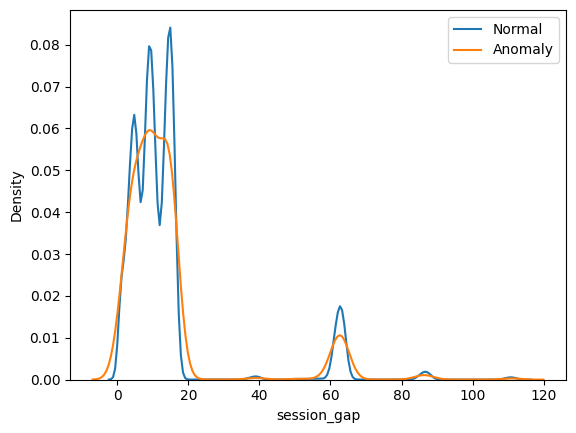

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df_result[df_result["is_injected"] == 0]["session_gap"], label="Normal")
sns.kdeplot(df_result[df_result["is_injected"] == 1]["session_gap"], label="Anomaly")

plt.legend()
plt.show()

<h2>Changing the approach....trying a role based detection along with the present pipeline
</h2>

In [26]:
df_user=pd.read_csv("../data/processed/user_profiles_v0.csv") #going back to the good old user dataset

In [27]:
df_user.shape

(4000, 19)

In [28]:
df_user

,employee_name,user_id,email,role,projects,business_unit,functional_unit,department,team,supervisor,start_date,end_date,tenure_days,is_new,has_supervisor,has_project,is_previliged,rare_role,risk_score
0,nicholas fletcher pruitt,NFP2441,nicholas.fletcher.pruitt@dtaa.com,itadmin,unassigned,1,1 - adminstration,5 - security,8 - electronicsecurity,madison charissa malone,2009-12-01,2011-06-01,547 days,0,1,0,1,0,0.45
1,abraham dante rodgers,ADR1517,abraham.dante.rodgers@dtaa.com,productionlineworker,unassigned,1,5 - manufacturing_commercial,3 - assembly,4 - assemblydept,mark william horne,2009-12-01,2011-06-01,547 days,0,1,0,0,0,0.15
2,medge wilma blackburn,MWB4000,medge.wilma.blackburn@dtaa.com,productionlineworker,unassigned,1,6 - manufacturing_government,3 - assembly,14 - assemblydept,hillary zenaida adkins,2009-12-01,2011-06-01,547 days,0,1,0,0,0,0.15
3,meghan laurel salazar,MLS2856,meghan.laurel.salazar@dtaa.com,productionlineworker,unassigned,1,6 - manufacturing_government,3 - assembly,8 - assemblydept,demetria sage melendez,2009-12-01,2011-06-01,547 days,0,1,0,0,0,0.15
4,beau todd romero,BTR2026,beau.todd.romero@dtaa.com,mechanicalengineer,unassigned,1,3 - researchandengineering_government_domestic,4 - engineering,16 - testandevalualtion,elijah valentine fuentes,2009-12-01,2011-06-01,547 days,0,1,0,0,0,0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,alfreda jeanette stephens,AJS0616,alfreda.jeanette.stephens@dtaa.com,softwaredeveloper,project 26,1,3 - researchandengineering_government_domestic,3 - softwaremanagement,2 - desktopsoftware,hedy ivana pennington,2009-12-01,2011-06-01,547 days,0,1,1,0,0,0.00
3996,zachery oscar mayer,ZOM0746,zachery.oscar.mayer@dtaa.com,electricalengineer,unassigned,1,4 - researchandengineering_government_foreign,3 - softwaremanagement,3 - embeddedsoftware,grant lamar fulton,2009-12-01,2011-06-01,547 days,0,1,0,0,0,0.15
3997,ginger jeanette trevino,GJT1292,ginger.jeanette.trevino@dtaa.com,electricalengineer,unassigned,1,3 - researchandengineering_government_domestic,4 - engineering,8 - electricalengineering,megan kalia dawson,2009-12-01,2011-06-01,547 days,0,1,0,0,0,0.15
3998,benjamin lucian duncan,BLD2227,benjamin.lucian.duncan@dtaa.com,productionlineworker,unassigned,1,6 - manufacturing_government,3 - assembly,6 - assemblydept,drew owen coleman,2009-12-01,2011-06-01,547 days,0,1,0,0,0,0.15


In [29]:
df_user.columns

Index(['employee_name', 'user_id', 'email', 'role', 'projects',
       'business_unit', 'functional_unit', 'department', 'team', 'supervisor',
       'start_date', 'end_date', 'tenure_days', 'is_new', 'has_supervisor',
       'has_project', 'is_previliged', 'rare_role', 'risk_score'],
      dtype='object')

In [30]:
cols_to_drop = [
    "employee_name",
    "email",
    "projects",
    "supervisor",
    "start_date",
    "end_date"
]

user_profiles_clean = df_user.drop(columns=cols_to_drop)
user_profiles_clean = user_profiles_clean.rename(columns={"user_id": "user"})

In [31]:
user_profiles_clean.columns

Index(['user', 'role', 'business_unit', 'functional_unit', 'department',
       'team', 'tenure_days', 'is_new', 'has_supervisor', 'has_project',
       'is_previliged', 'rare_role', 'risk_score'],
      dtype='object')

In [32]:
df_merged = df_result.merge(
    user_profiles_clean,
    on="user",
    how="left"
)

In [45]:
df_merged.columns

Index(['user', 'window', 'logon_count', 'logoff_count', 'unique_pcs', 'hour',
       'z_logon', 'z_pcs', 'night_flag', 'behavior_score', 'logon_deviation',
       'device_deviation', 'logon_logoff_ratio', 'burst_score', 'device_ratio',
       'hour_deviation', 'session_gap', 'night_activity_flag', 'is_ingested',
       'is_injected', 'anomaly_type', 'avg_logon', 'std_logon', 'avg_pcs',
       'std_pcs', 'Shift', 'cluster_id', 'cluster_if_score', 'cluster_if_pred',
       'is_cluster_anomaly', 'is_anomaly_final', 'role', 'business_unit',
       'functional_unit', 'department', 'team', 'tenure_days', 'is_new',
       'has_supervisor', 'has_project', 'is_previliged', 'rare_role',
       'risk_score'],
      dtype='object')

In [33]:
df_merged

,user,window,logon_count,logoff_count,unique_pcs,hour,z_logon,z_pcs,night_flag,behavior_score,...,functional_unit,department,team,tenure_days,is_new,has_supervisor,has_project,is_previliged,rare_role,risk_score
0,AAB0398,2010-01-04 15:00:00,0,1,1,15,-0.559836,-0.073959,False,0.399719,...,9 - salesandmarketing_government,unassigned,unassigned,547 days,0,1,0,1,0,0.45
1,AAB0162,2010-01-04 18:00:00,0,1,1,18,-0.678264,-0.051486,False,0.399157,...,3 - researchandengineering_government_domestic,3 - softwaremanagement,3 - embeddedsoftware,547 days,0,1,0,0,0,0.15
2,AAB0162,2010-01-04 07:00:00,1,0,1,7,0.574322,-0.051486,False,0.400281,...,3 - researchandengineering_government_domestic,3 - softwaremanagement,3 - embeddedsoftware,547 days,0,1,0,0,0,0.15
3,AAB0162,2010-01-05 07:00:00,1,0,1,7,0.574322,-0.051486,False,0.400281,...,3 - researchandengineering_government_domestic,3 - softwaremanagement,3 - embeddedsoftware,547 days,0,1,0,0,0,0.15
4,AAB0398,2010-01-05 15:00:00,0,1,1,15,-0.559836,-0.073959,False,0.399719,...,9 - salesandmarketing_government,unassigned,unassigned,547 days,0,1,0,1,0,0.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3366259,ZZO2997,2011-05-24 07:00:00,1,0,1,7,0.555970,-0.051449,False,0.399719,...,2 - researchandengineering_commercial,2 - research,5 - lab,547 days,0,1,0,1,0,0.45
3366260,ZZO2997,2011-05-25 07:00:00,1,0,1,7,0.555970,-0.051449,False,0.399719,...,2 - researchandengineering_commercial,2 - research,5 - lab,547 days,0,1,0,1,0,0.45
3366261,ZZO2997,2011-05-26 07:00:00,1,0,1,7,0.555970,-0.051449,False,0.399719,...,2 - researchandengineering_commercial,2 - research,5 - lab,547 days,0,1,0,1,0,0.45
3366262,ZZO2997,2011-05-27 07:00:00,1,0,1,7,0.555970,-0.051449,False,0.399719,...,2 - researchandengineering_commercial,2 - research,5 - lab,547 days,0,1,0,1,0,0.45


In [34]:
df_merged.isna().sum().sort_values(ascending=False).head(10)

user                  0
business_unit         0
std_pcs               0
Shift                 0
cluster_id            0
cluster_if_score      0
cluster_if_pred       0
is_cluster_anomaly    0
is_anomaly_final      0
role                  0
dtype: int64

In [35]:
df_merged["role"].isna().mean()

0.0

In [38]:
len(list(set(df_result["user"]).intersection(set(user_profiles_clean["user"]))))

4000

In [41]:
df_merged['role'].nunique()

46

In [46]:
df_merged['role'].value_counts().head(10)

role
productionlineworker    340839
electricalengineer      339525
technician              332731
salesman                297986
mechanicalengineer      236802
stockroomclerk          228350
itadmin                 173827
materialsengineer        96674
hardwareengineer         93144
scientist                89854
Name: count, dtype: int64

In [44]:
df_merged['role'].value_counts().tail(10)

role
industrialengineer          2946
attorney                    2606
accountant                  2564
healthsafetyengineer        1166
nurse                       1149
president                   1117
financialanalyst             993
instructionalcoordinator     712
economist                    712
administrativestaff          712
Name: count, dtype: int64

In [50]:
df_merged['role'].unique()

array(['administrativeassistant', 'hardwareengineer',
       'softwarequalityengineer', 'mechanicalengineer', 'systemsengineer',
       'stockroomclerk', 'productionlineworker', 'securityguard',
       'salesman', 'physicist', 'statistician', 'softwareengineer',
       'webdeveloper', 'scientist', 'technician', 'softwaredeveloper',
       'testengineer', 'electricalengineer', 'accountant',
       'mathematician', 'vicepresident', 'computerscientist', 'itadmin',
       'labmanager', 'director', 'manager', 'technicalwriter',
       'computerprogrammer', 'materialsengineer', 'attorney',
       'projectmanager', 'supervisor', 'chiefengineer',
       'industrialengineer', 'nurse', 'nursepractitioner',
       'financialanalyst', 'engineer', 'fieldserviceengineer',
       'humanresourcespecialist', 'purchasingclerk',
       'instructionalcoordinator', 'president', 'economist',
       'healthsafetyengineer', 'administrativestaff'], dtype=object)

In [65]:
#performing grouping of all the 46 roles

role_group_map = {

# SOFTWARE ENGINEERING
"softwareengineer": "software_engineering",
"softwaredeveloper": "software_engineering",
"webdeveloper": "software_engineering",
"softwarequalityengineer": "software_engineering",
"testengineer": "software_engineering",
"computerprogrammer": "software_engineering",
"computerscientist": "software_engineering",

# INDUSTRIAL / HARDWARE ENGINEERING
"electricalengineer": "industrial_engineering",
"mechanicalengineer": "industrial_engineering",
"materialsengineer": "industrial_engineering",
"industrialengineer": "industrial_engineering",
"fieldserviceengineer": "industrial_engineering",
"systemsengineer": "industrial_engineering",
"chiefengineer": "industrial_engineering",
"engineer": "industrial_engineering",
'hardwareengineer': "industrial_engineering",
'healthsafetyengineer':"industrial_engineering",

# SCIENTIFIC / ANALYTICAL
"scientist": "scientific_research",
"physicist": "scientific_research",
"statistician": "scientific_research",
"mathematician": "scientific_research",
"economist": "scientific_research",

# OPERATIONS
"productionlineworker": "operations",
"technician": "operations",
"labmanager": "operations",
"supervisor": "operations",

# SALES
"salesman": "sales",

# IT / ADMIN
"itadmin": "it_admin",
"securityguard": "it_admin",

# LOGISTICS
"stockroomclerk": "logistics",
"purchasingclerk": "logistics",

# MANAGEMENT
"manager": "management",
"projectmanager": "management",
"director": "management",
"vicepresident": "management",
"president": "management",

# ADMIN STAFF
"administrativeassistant": "admin_staff",
"administrativestaff": "admin_staff",
"humanresourcespecialist": "admin_staff",
"instructionalcoordinator": "admin_staff",
"technicalwriter": "admin_staff",

# MERGED SMALL GROUPS
"accountant": "admin_staff",
"financialanalyst": "admin_staff",
"attorney": "admin_staff",
"nurse": "admin_staff",
"nursepractitioner": "admin_staff"
}
len(role_group_map.keys())

46

In [67]:
df_merged["role_group"] = df_merged["role"].map(role_group_map).fillna("other")

In [72]:
df_merged['role_group'].value_counts().sum()

3366264

In [73]:
def split_by_shift(df):
    
    day_mask = (df["hour"] >= 9) & (df["hour"] <= 16)
    evening_mask = (df["hour"] >= 17) & (df["hour"] <= 21)
    night_mask = (df["hour"] >= 22) | (df["hour"] <= 8)

    shifts = {
        "day": df[day_mask].copy(),
        "evening": df[evening_mask].copy(),
        "night": df[night_mask].copy()
    }

    return shifts

In [74]:
shift_data = split_by_shift(df_merged)

In [75]:
def split_by_role_group(df_shift):

    role_groups = {}

    for group in df_shift["role_group"].unique():

        role_groups[group] = df_shift[df_shift["role_group"] == group].copy()

    return role_groups

In [76]:
def build_context_datasets(df):

    contexts = {}

    shift_data = split_by_shift(df)

    for shift_name, df_shift in shift_data.items():

        role_groups = split_by_role_group(df_shift)

        contexts[shift_name] = role_groups

    return contexts

In [79]:
context_data = build_context_datasets(df_merged)
context_data

{'day': {'admin_staff':             user              window  logon_count  logoff_count  unique_pcs  \
  0        AAB0398 2010-01-04 15:00:00            0             1           1   
  4        AAB0398 2010-01-05 15:00:00            0             1           1   
  7        AAB0398 2010-01-06 15:00:00            0             1           1   
  11       AAB0398 2010-01-07 15:00:00            0             1           1   
  14       AAB0398 2010-01-08 15:00:00            0             1           1   
  ...          ...                 ...          ...           ...         ...   
  2967410  YSH0145 2011-05-17 16:00:00            0             1           1   
  2967412  YSH0145 2011-05-19 16:00:00            0             1           1   
  2967414  YSH0145 2011-05-20 16:00:00            0             1           1   
  2967416  YSH0145 2011-05-25 16:00:00            0             1           1   
  2967418  YSH0145 2011-05-31 16:00:00            0             1           1   
  
   

In [80]:
context_data["day"]["software_engineering"]

,user,window,logon_count,logoff_count,unique_pcs,hour,z_logon,z_pcs,night_flag,behavior_score,...,department,team,tenure_days,is_new,has_supervisor,has_project,is_previliged,rare_role,risk_score,role_group
1061,AAC0610,2010-01-05 14:00:00,1,0,1,14,0.617351,-0.043225,False,0.304209,...,3 - softwaremanagement,1 - sqa,547 days,0,1,1,0,0,0.0,software_engineering
1062,AAC0610,2010-01-05 16:00:00,0,1,1,16,-1.111231,-0.043225,False,0.525453,...,3 - softwaremanagement,1 - sqa,547 days,0,1,1,0,0,0.0,software_engineering
1066,AAC0610,2010-01-06 16:00:00,0,1,1,16,-1.111231,-0.043225,False,0.525453,...,3 - softwaremanagement,1 - sqa,547 days,0,1,1,0,0,0.0,software_engineering
1070,AAC0610,2010-01-07 13:00:00,1,0,1,13,0.617351,-0.043225,False,0.304209,...,3 - softwaremanagement,1 - sqa,547 days,0,1,1,0,0,0.0,software_engineering
1072,AAC0610,2010-01-07 16:00:00,0,1,1,16,-1.111231,-0.043225,False,0.525453,...,3 - softwaremanagement,1 - sqa,547 days,0,1,1,0,0,0.0,software_engineering
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2991977,ZRM0694,2011-05-29 15:00:00,0,1,1,15,-0.946564,-0.116528,False,0.556547,...,4 - engineering,5 - systemsengineering,547 days,0,1,1,0,0,0.0,software_engineering
2991978,ZRM0694,2011-05-30 11:00:00,1,0,1,11,0.479844,-0.116528,False,0.328206,...,4 - engineering,5 - systemsengineering,547 days,0,1,1,0,0,0.0,software_engineering
2991980,ZRM0694,2011-05-30 15:00:00,0,1,1,15,-0.946564,-0.116528,False,0.556547,...,4 - engineering,5 - systemsengineering,547 days,0,1,1,0,0,0.0,software_engineering
2991982,ZRM0694,2011-05-31 11:00:00,1,0,1,11,0.479844,-0.116528,False,0.328206,...,4 - engineering,5 - systemsengineering,547 days,0,1,1,0,0,0.0,software_engineering


In [81]:
CLUSTER_FEATURES = [
    "logon_count",
    "logoff_count",
    "unique_pcs",
    "z_logon",
    "z_pcs",
    "session_gap",
    "burst_score",
    "hour_deviation",
    "device_ratio"
]

In [85]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


def run_behavior_clustering(context_data, features, n_clusters=2):

    clustered_data = {}
    kmeans_models = {}

    for shift, role_dict in context_data.items():

        clustered_data[shift] = {}
        kmeans_models[shift] = {}

        for role_group, df_context in role_dict.items():

            # Skip very small contexts
            if len(df_context) < 500:
                continue

            df_context = df_context.copy()

            # Prepare feature matrix
            X = df_context[features].replace([np.inf, -np.inf], np.nan).fillna(0)

            # Scale features
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            # Run KMeans
            kmeans = KMeans(
                n_clusters=n_clusters,
                random_state=42,
                n_init=10
            )

            cluster_labels = kmeans.fit_predict(X_scaled)

            # Assign clusters
            df_context["cluster_id"] = cluster_labels

            # Store results
            clustered_data[shift][role_group] = df_context
            kmeans_models[shift][role_group] = kmeans

            print(f"{shift} | {role_group} | rows: {len(df_context)}")

    return clustered_data, kmeans_models

In [88]:
clustered_contexts, kmeans_models = run_behavior_clustering(
    context_data,
    CLUSTER_FEATURES
)

day | admin_staff | rows: 56553
day | software_engineering | rows: 129626
day | industrial_engineering | rows: 307934
day | logistics | rows: 73131
day | operations | rows: 239006
day | it_admin | rows: 52706
day | sales | rows: 74053
day | scientific_research | rows: 84889
day | management | rows: 34358
evening | industrial_engineering | rows: 240071
evening | software_engineering | rows: 111938
evening | operations | rows: 170999
evening | sales | rows: 100585
evening | scientific_research | rows: 65649
evening | admin_staff | rows: 35196
evening | logistics | rows: 61406
evening | management | rows: 31674
evening | it_admin | rows: 74270
night | industrial_engineering | rows: 386673
night | admin_staff | rows: 63696
night | software_engineering | rows: 170932
night | logistics | rows: 98906
night | operations | rows: 303482
night | it_admin | rows: 129823
night | sales | rows: 123348
night | scientific_research | rows: 102788
night | management | rows: 42572


In [89]:
clustered_contexts["day"]["software_engineering"]["cluster_id"].value_counts()

cluster_id
1    70672
0    58954
Name: count, dtype: int64

In [90]:
for shift in clustered_contexts:
    for role in clustered_contexts[shift]:
        print(shift, role)
        print(clustered_contexts[shift][role]["cluster_id"].value_counts())
        print()

day admin_staff
cluster_id
1    32081
0    24472
Name: count, dtype: int64

day software_engineering
cluster_id
1    70672
0    58954
Name: count, dtype: int64

day industrial_engineering
cluster_id
1    164256
0    143678
Name: count, dtype: int64

day logistics
cluster_id
0    41027
1    32104
Name: count, dtype: int64

day operations
cluster_id
1    138072
0    100934
Name: count, dtype: int64

day it_admin
cluster_id
1    29184
0    23522
Name: count, dtype: int64

day sales
cluster_id
0    46168
1    27885
Name: count, dtype: int64

day scientific_research
cluster_id
0    45940
1    38949
Name: count, dtype: int64

day management
cluster_id
1    18913
0    15445
Name: count, dtype: int64

evening industrial_engineering
cluster_id
0    238997
1      1074
Name: count, dtype: int64

evening software_engineering
cluster_id
0    111386
1       552
Name: count, dtype: int64

evening operations
cluster_id
0    170242
1       757
Name: count, dtype: int64

evening sales
cluster_id
0    10

<p>This analysis above shows that the clustering performed is effective in the day shift but not effective in the evening and night shift which led to the decision that IF is performed directly on the (shift+group) for both evening and night</p>

In [91]:
df_merged.groupby(["Shift","role_group"])["logon_count"].std()

Shift    role_group            
Day      admin_staff               0.632986
         industrial_engineering    0.627865
         it_admin                  0.647094
         logistics                 0.639627
         management                0.680338
         operations                0.625167
         sales                     0.622786
         scientific_research       0.629778
         software_engineering      0.625082
Evening  admin_staff               0.456016
         industrial_engineering    0.402025
         it_admin                  0.728781
         logistics                 0.393155
         management                0.384975
         operations                0.399783
         sales                     0.389153
         scientific_research       0.418376
         software_engineering      0.407574
Night    admin_staff               0.791061
         industrial_engineering    0.741392
         it_admin                  0.807176
         logistics                 0.712018


In [92]:
df_merged.to_csv("../data/processed/behavior_dataset_v5_features.csv", index=False)